In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from PycalcAct.dataset import Dataset
from PycalcAct.model import (
    MixedFCTemporalModel)
from PycalcAct.trainer import Trainer
from PycalcAct.calculateCustomAccuracy import calculateCustomAccuracy
from pathlib import Path
from PycalcAct.myCustomCriterion import myCustomCriterion
_ = torch.manual_seed(1234)


dataFolder = "//Hmr_lymph/d/SebastienThis/CalciumPredictions/Ca2-Analysis_McGill/prediction/agAffinity/datasets/trainingData/"
#dataFolder = "D:/Ca2-Analysis_McGill/prediction/agAffinity/datasets/trainingData/"

csv_path=[dataFolder + "legend.csv", dataFolder+"calciumRatio_normalized.csv"] 
csv_pos_path = dataFolder + "position.csv"

dataset = Dataset(
    csv_path = csv_path,
    csv_pos_path=csv_pos_path,  # Optional
    position_to_displacement=True,
    remove_mean=False,
    replace_nan_by_min = True,
    customFilter = False,
    is_regression = False, #True
)
dataset.create_new_feature_by_operations(lambda x: np.abs(np.fft.fft(x[:, 0])))

# Setup model
model = MixedFCTemporalModel(
    n_classes=4, #1,
    n_rnn_layers=3,
    rnn_hidden_size=32,
    n_fc_layers=1,
    fc_hidden_size=32,
    temporal_length=dataset.length_serie,
    input_size=dataset.features,
    bidirectional=True,
    pooling=None,
    dropout=0.2
)   

# Setup training
n_epochs = 100
        
trainer = Trainer(
    dataset,
    model,
    device="cuda",
    batch_size=2500,
    criterion=None,
    is_regression=False, #True,
    regression_bounds_y = None,#torch.Tensor([-12,-10,-9]).to("cuda")
)  # You can pass your own optimizer, criterion, learning rate, weight decay and learning rate scheduler.


In [7]:
trainer.summary()   
trainer.train(n_epochs)
print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Data
Dataset summary: timepoints 120, features 3
Features:
calciumRatio_normalized Displacement <lambda>
Class weights:
╭───────────────────────────┬───────────────────────────┬───────────────────────────╮
│           Epoch           │                      Loss │                  Accuracy │
├───────────────────────────┼───────────────────────────┼───────────────────────────┤
│             0             │                      1.30 │                     22.44 │
│             1             │                      1.21 │                     49.71 │
│             3             │                      1.16 │                     50.31 │
│             4             │                      1.17 │                     51.42 │
│             8             │                      1.10 │                     53.56 │
│             10            │                      1.06 │                     54.85 │
│             16            │                      1.06 │                     54.87 │
│             20    

D:\Sebastien\PycalcActivation\src\PycalcAct\trainer.py:271: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


{'Accuracy': tensor(0.6058, device='cuda:0'),
 'CohenKappa': tensor(0.4290, device='cuda:0')}

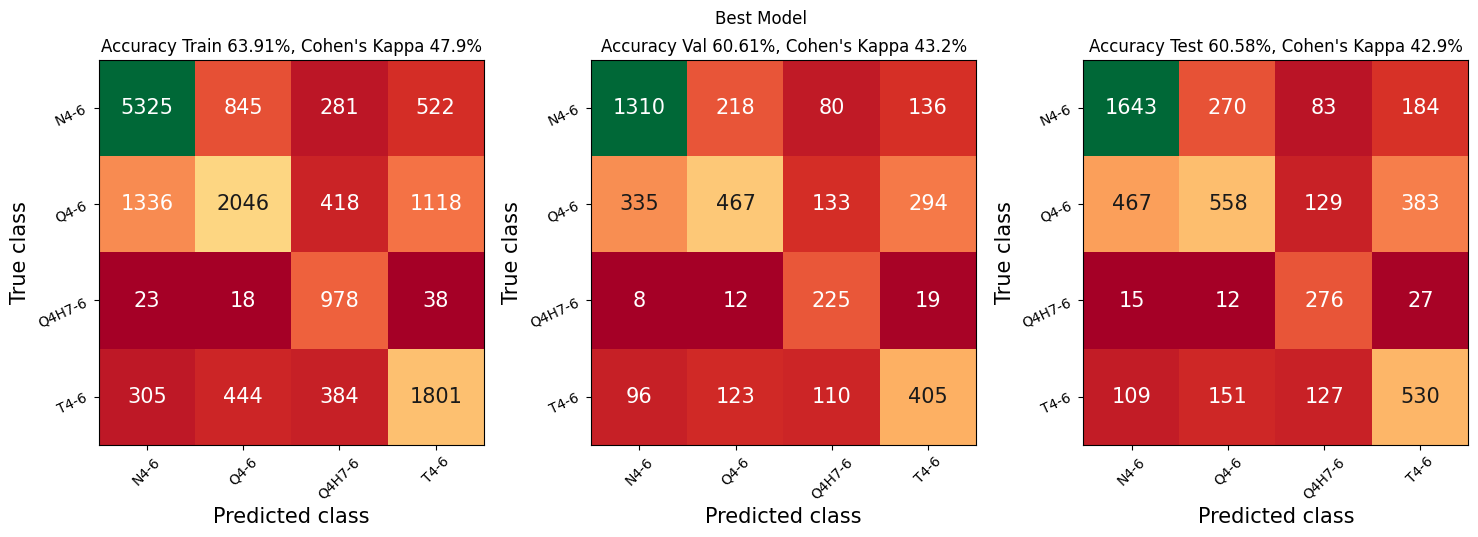

In [8]:
trainer.test("best")

In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from PycalcAct.dataset import Dataset
from PycalcAct.model import (
    MixedFCTemporalModel)
from PycalcAct.trainer import Trainer
from pathlib import Path
from PycalcAct.myCustomCriterion import myCustomCriterion
_ = torch.manual_seed(1234)

dataFolder = "//Hmr_lymph/d/SebastienThis/CalciumPredictions/Ca2-Analysis_McGill/prediction/agAffinity/datasets/trainingData/"
# dataFolder = "D:/Ca2-Analysis_McGill/prediction/agAffinity/datasets/trainingData/"

csv_path=[dataFolder + "legend.csv", dataFolder+"calciumRatio_normalized.csv"] 
csv_pos_path = dataFolder + "position.csv"

dataset2 = Dataset(
    csv_path = csv_path,
    csv_pos_path=csv_pos_path,  # Optional
    position_to_displacement=True,
    remove_mean=False,
    replace_nan_by_min = True,
    customFilter = False,
    is_regression = True,
	augment_gt = "rand", # "rand" or "Ca"
)
dataset2.create_new_feature_by_operations(lambda x: np.abs(np.fft.fft(x[:, 0])))

# Setup model
model2 = MixedFCTemporalModel(
    n_classes= 1,
    n_rnn_layers=3,
    rnn_hidden_size=32,
    n_fc_layers=1,
    fc_hidden_size=32,
    temporal_length=dataset2.length_serie,
    input_size=dataset2.features,
    bidirectional=True,
    pooling=None,
    dropout=0.2
)   

# Setup training

        
trainer2 = Trainer(
    dataset2,
    model2,
    device="cuda",
    batch_size=2500,
    criterion=None,
    is_regression=True,        
    use_class_weights=False,
    regression_bounds_y = torch.Tensor([0.5,1.5,2.5]).to("cuda"),
    regression_bounds_y_pred = torch.Tensor([0.5,0.8,1.7]).to("cuda"),#torch.Tensor([-12,-10,-9]).to("cuda")
)  # You can pass your own optimizer, criterion, learning rate, weight decay and learning rate scheduler.

trainer2.summary()   

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

[0 0 0 ... 2 2 2]


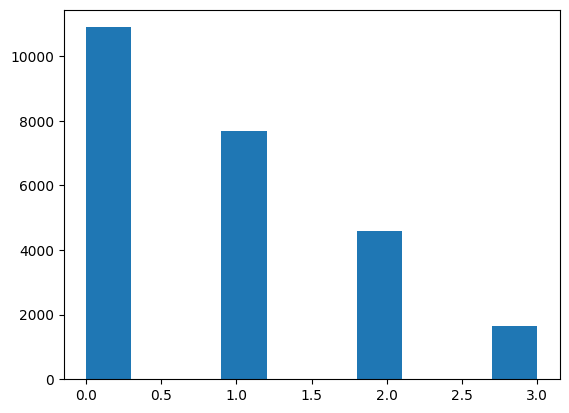

In [2]:
# test = trainer2.dataset.classes_int
# f = trainer2.dataset.f.data
# # test = [t+(0.5-np.random.rand())*0.5 for t in test]
# # print(len(test))
# # print(f.squeeze().shape)
# meanCa = np.mean(f,2)
# # print(meanCa.shape)
# print(test)
# print(meanCa)
# test = test - (meanCa.squeeze()-min(meanCa))/(max(meanCa))-min(meanCa)*0.4
# print(test)
# plt.scatter(test, test)
# plt.show()

print(trainer2.dataset.classes_int)
plt.hist(trainer2.dataset.classes_int)
plt.show()

╭───────────────────────────┬───────────────────────────┬───────────────────────────╮
│           Epoch           │                      Loss │                  Accuracy │
├───────────────────────────┼───────────────────────────┼───────────────────────────┤
│             0             │                      1.30 │                     43.92 │
│             7             │                      0.76 │                     49.91 │
│             9             │                      0.85 │                     52.51 │
│             12            │                      0.72 │                     53.69 │
│             49            │                      0.73 │                           │
╰───────────────────────────┴───────────────────────────┴───────────────────────────╯


D:\Sebastien\PycalcActivation\src\PycalcAct\trainer.py:276: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


{'Accuracy': tensor(0.5161, device='cuda:0'),
 'CohenKappa': tensor(0.2871, device='cuda:0')}

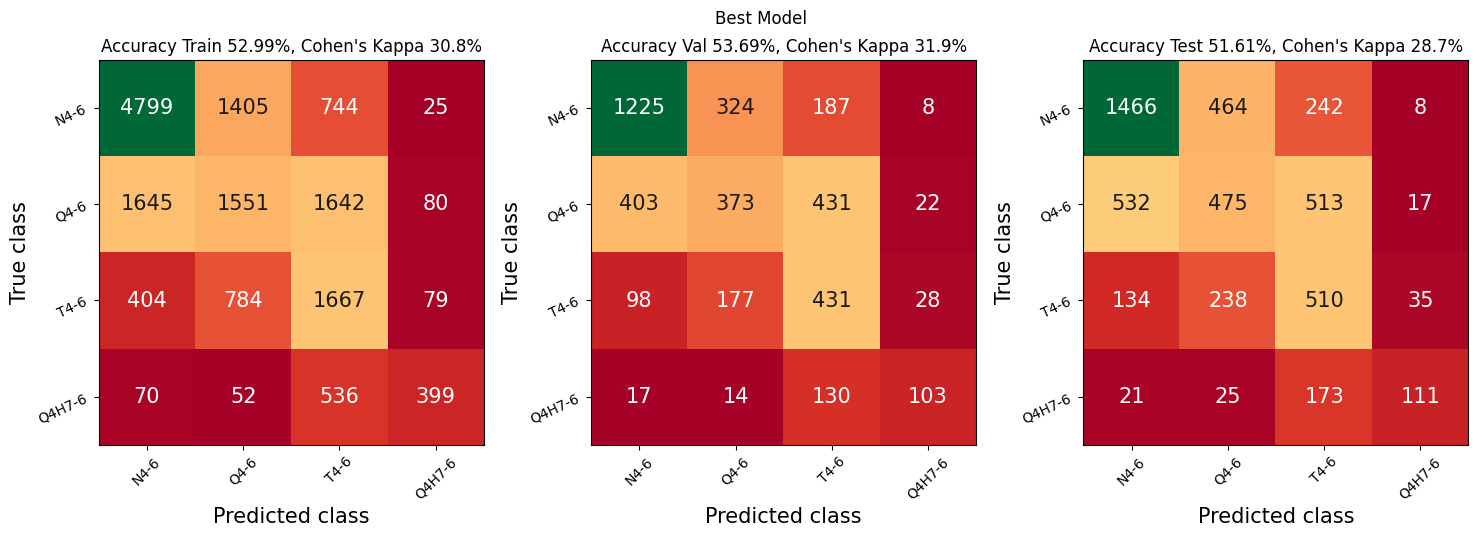

In [4]:
n_epochs = 50
trainer2.train(n_epochs)
trainer2.test("best")

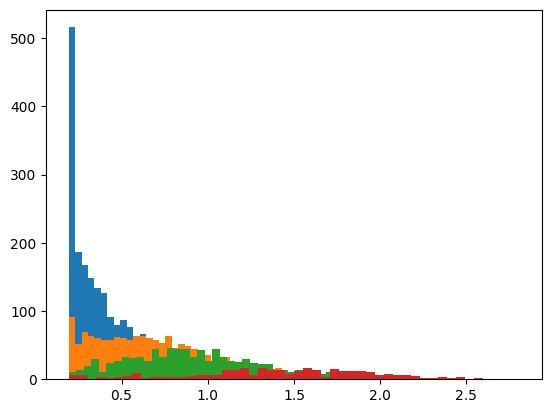

tensor([0, 3, 0,  ..., 0, 0, 0], device='cuda:0')


In [6]:
x, y = trainer2.dataset.test_batch(True, to_cuda=True)
y_pred = trainer2.model(torch.Tensor(x))
plt.hist(y_pred[y == 0].cpu().detach().numpy(), 50)
plt.hist(y_pred[y == 1].cpu().detach().numpy(), 50)
plt.hist(y_pred[y == 2].cpu().detach().numpy(), 50)
plt.hist(y_pred[y == 3].cpu().detach().numpy(), 50)
plt.show()
print(y)

Data
Dataset summary: timepoints 120, features 3
Features:
calciumRatio_normalized Displacement <lambda>
Class weights:
╭───────────────────────────┬───────────────────────────┬───────────────────────────╮
│           Epoch           │                      Loss │                  Accuracy │
├───────────────────────────┼───────────────────────────┼───────────────────────────┤
│             0             │                      1.76 │                     49.87 │
│            499            │                      0.62 │                           │
╰───────────────────────────┴───────────────────────────┴───────────────────────────╯


D:\sebastien\PycalcActivation\src\PycalcAct\trainer.py:271: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


{'Accuracy': tensor(0.4999, device='cuda:0'),
 'CohenKappa': tensor(0.2094, device='cuda:0')}

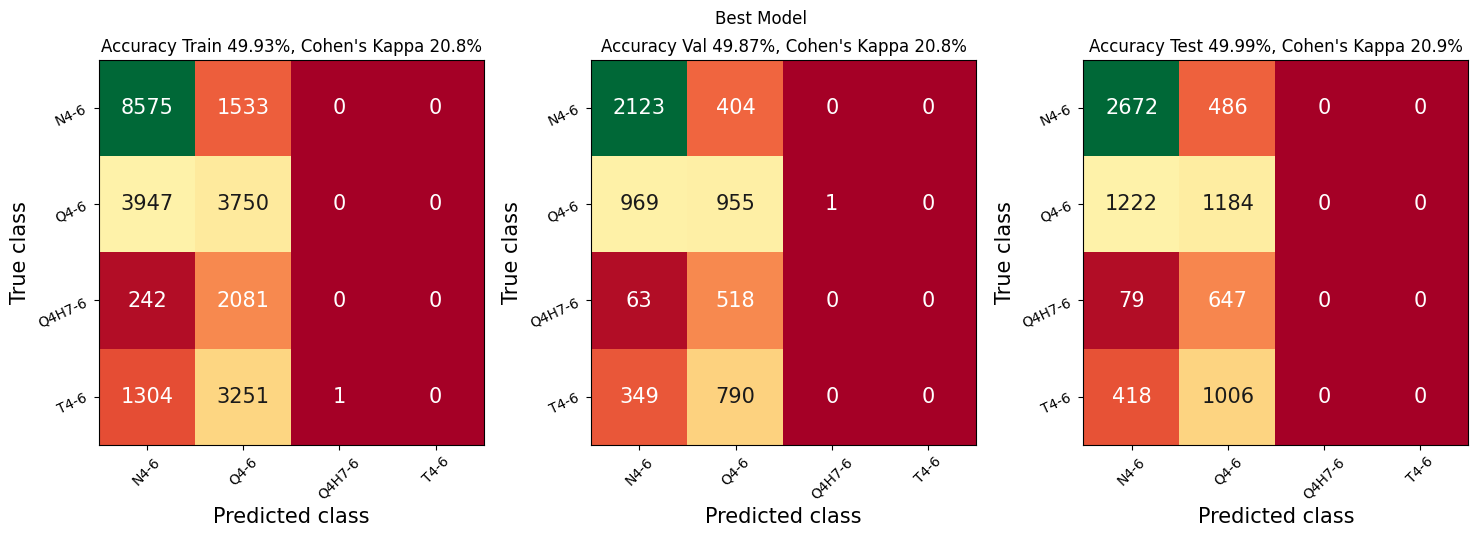

In [ ]:
trainer3 = Trainer(
    dataset2,
    model2,
    device="cuda",
    batch_size=5000,
    criterion=None,
    is_regression=True,        
    use_class_weights=True,
    regression_bounds_y = torch.Tensor([0.5,1.5,2.5]).to("cuda") #torch.Tensor([-12,-10,-9]).to("cuda")
)  # You can pass your own optimizer, criterion, learning rate, weight decay and learning rate scheduler.

trainer3.summary()
trainer3.train(n_epochs)
trainer3.test("best")  

In [ ]:
from progress_table import ProgressTable
from copy import deepcopy
from torchmetrics.classification import Accuracy, CohenKappa, ConfusionMatrix
from torch import tensor

if trainer2.scheduler is None:
    trainer2.scheduler = trainer2.default_scheduler()(T_max=n_epochs)
    trainer2._initial_scheduler_state_dict = deepcopy(trainer2.scheduler.state_dict())
    trainer2._initial_scheduler_state_dict = deepcopy(trainer2.scheduler.state_dict())

x, y = trainer2.dataset.train_batch(True, to_cuda=True)
batch_size = len(x) if trainer2.batch_size is None else trainer2.batch_size

current_best = 0
xval, yval = trainer2.dataset.val_batch(True, to_cuda=True)
table = ProgressTable(
    num_decimal_places=2,
    print_header_every_n_rows=15,
    # print_header_every_n_rows=15,
    pbar_show_progress=True,
    pbar_style="square",
    default_column_width=25,
)

table.add_column("Epoch")
table.add_column("Loss", color="blue", alignment="right")
table.add_column(trainer2._store_best, color="green", alignment="right")
table.add_column("Loss", color="blue", alignment="right")
table.add_column(trainer2._store_best, color="green", alignment="right")

for e in table(
    range(n_epochs),
    total=n_epochs,
    description="Epoch",
    show_eta=True,
):
    idx = torch.randperm(x.shape[0], device=x.device)
    x = x[idx]
    y = y[idx]

    trainer2.model.train()
    for i in range(0, len(x), batch_size):
        trainer2.optim.zero_grad()
        x_batch = x[i : i + batch_size]
        if trainer2.is_regression:
            y_batch = y[i : i + batch_size].type(torch.FloatTensor).to(trainer2.device)
        else:
            y_batch = y[i : i + batch_size].type(torch.LongTensor).to(trainer2.device)
        # Take batch size:

        with torch.autocast("cuda"): #torch.cuda.amp.autocast()
            y_pred = trainer2.model(x_batch)
            loss = trainer2.criterion(y_pred, y_batch, weight=trainer2.dataset.weights)
            
        
        loss.backward()
        trainer2.optim.step()
    print(loss)
    thisParam = trainer2.model.final_layer.parameters()
    for p in thisParam:
        print(p.grad)

    if trainer2.scheduler:
        trainer2.scheduler.step()
    # table.update("Loss", loss.item(), aggregate="mean", color="blue")
    # table.update("Epoch", e)
    # table.update("Loss", loss.item(), aggregate="mean", color="blue")
    # table.update("Epoch", e)
    # if e % 10 == 0:
    #     if trainer2.is_regression:
    #         loss, scores = trainer2.eval(xval, yval.type(torch.FloatTensor).to(trainer2.device))
    #     else:
    #         loss, scores = trainer2.eval(xval, yval.type(torch.LongTensor).to(trainer2.device))
    #     if scores[trainer2._store_best] > current_best:
    #         current_best = scores[trainer2._store_best]
    #         trainer2._best_state_dict = deepcopy(trainer2.model.state_dict())
    #         if True:
    #             table.update(trainer2._store_best, scores[trainer2._store_best].item() * 100, color="green")
    #             table.update(trainer2._store_best, scores[trainer2._store_best].item() * 100, color="green")

    #         table.next_row()

TypeError: myMSELoss.__call__() got an unexpected keyword argument 'weight'